In [ ]:
# Teammate load cell
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_train = pd.read_csv("../feature_eng_dataset/train_features.csv")
df_test = pd.read_csv("../feature_eng_dataset/test_features.csv")
df_test_unlabled=pd.read_csv("../feature_eng_dataset/test_features_opt.csv")

#We only keep the ones with label=0 to for later testing on unlabeled data
df_test_zeros=df_test_unlabled[df_test_unlabled['label']==0].copy()

df_val=df_train[df_train['image'] == "O012791"].copy()
df_train=df_train[df_train['image'] == "O013257"].copy()

df_val.drop(columns=["image"], inplace=True)
df_train.drop(columns=["image"], inplace=True)

ae_cols = [c for c in df_train.columns if c.startswith("ae")]
FEATURE_COLS = ["SD", "CORR", "DF", "CF", "BF", "AF", "AN", "NDAI_DF_AF", "PC1"] 

X_train, y_train = df_train[FEATURE_COLS], df_train["label"]
X_test, y_test = df_test[FEATURE_COLS], df_test["label"]
X_val, y_val = df_val[FEATURE_COLS], df_val["label"]
X_test_unlabled, y_test_unlabled = df_test_zeros[FEATURE_COLS], df_test_zeros["label"]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test_unlabled  : {X_test_unlabled.shape}")
print(f"Number of AE features: {len(ae_cols)}")
print(f"Features: {FEATURE_COLS}")

X_train : (70826, 9)
X_test  : (82083, 9)
X_val  : (54772, 9)
X_test_unlabled  : (32949, 9)
Number of AE features: 32
Features: ['SD', 'CORR', 'DF', 'CF', 'BF', 'AF', 'AN', 'NDAI_DF_AF', 'PC1']


In [11]:
pd.unique(y_test_unlabled)

array([0.])

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

#The selection process is rather time-consuming
#Please run svm.py and check out for svm.output for the variable selection results
SVM_COLS = ["SD", "CORR", "NDAI_DF_AF"] 


X_train_svm = df_train[SVM_COLS]
X_test_svm = df_test[SVM_COLS]

X_val_svm = df_val[SVM_COLS]


    
print("Running SVM (RBF Kernel)...")
# Standard SVM (C=1.0, RBF kernel)
svm = SVC(kernel='rbf', gamma=1.0, C=1.0)
svm.fit(X_train_svm, y_train)

#Get performance
svm_preds = svm.predict(X_val_svm)
y_pred_svm = svm.predict(X_test_svm)

#Print out performances
svm_acc = accuracy_score(y_val, svm_preds)
print(f"SVM Accuracy: {svm_acc}")

svm_test_acc=accuracy_score(y_test, y_pred_svm)



print("SUMMARY OF RESULTS")


print(f"SVM Accuracy on Validation Set:    {svm_acc}")
print(f"SVM Accuracy on Test Set:   {svm_test_acc}")
print("Detailed SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print(f"SVM ROC AUC on Test Set: {roc_auc_score(y_test, y_pred_svm)}")


Running SVM (RBF Kernel)...
SVM Accuracy: 0.8358832980354926
SUMMARY OF RESULTS
SVM Accuracy on Validation Set:    0.8358832980354926
SVM Accuracy on Test Set:   0.9471632372111156
Detailed SVM Classification Report:
              precision    recall  f1-score   support

        -1.0       0.98      0.91      0.95     42830
         1.0       0.91      0.98      0.95     39253

    accuracy                           0.95     82083
   macro avg       0.95      0.95      0.95     82083
weighted avg       0.95      0.95      0.95     82083

SVM ROC AUC on Test Set: 0.9486813094212209


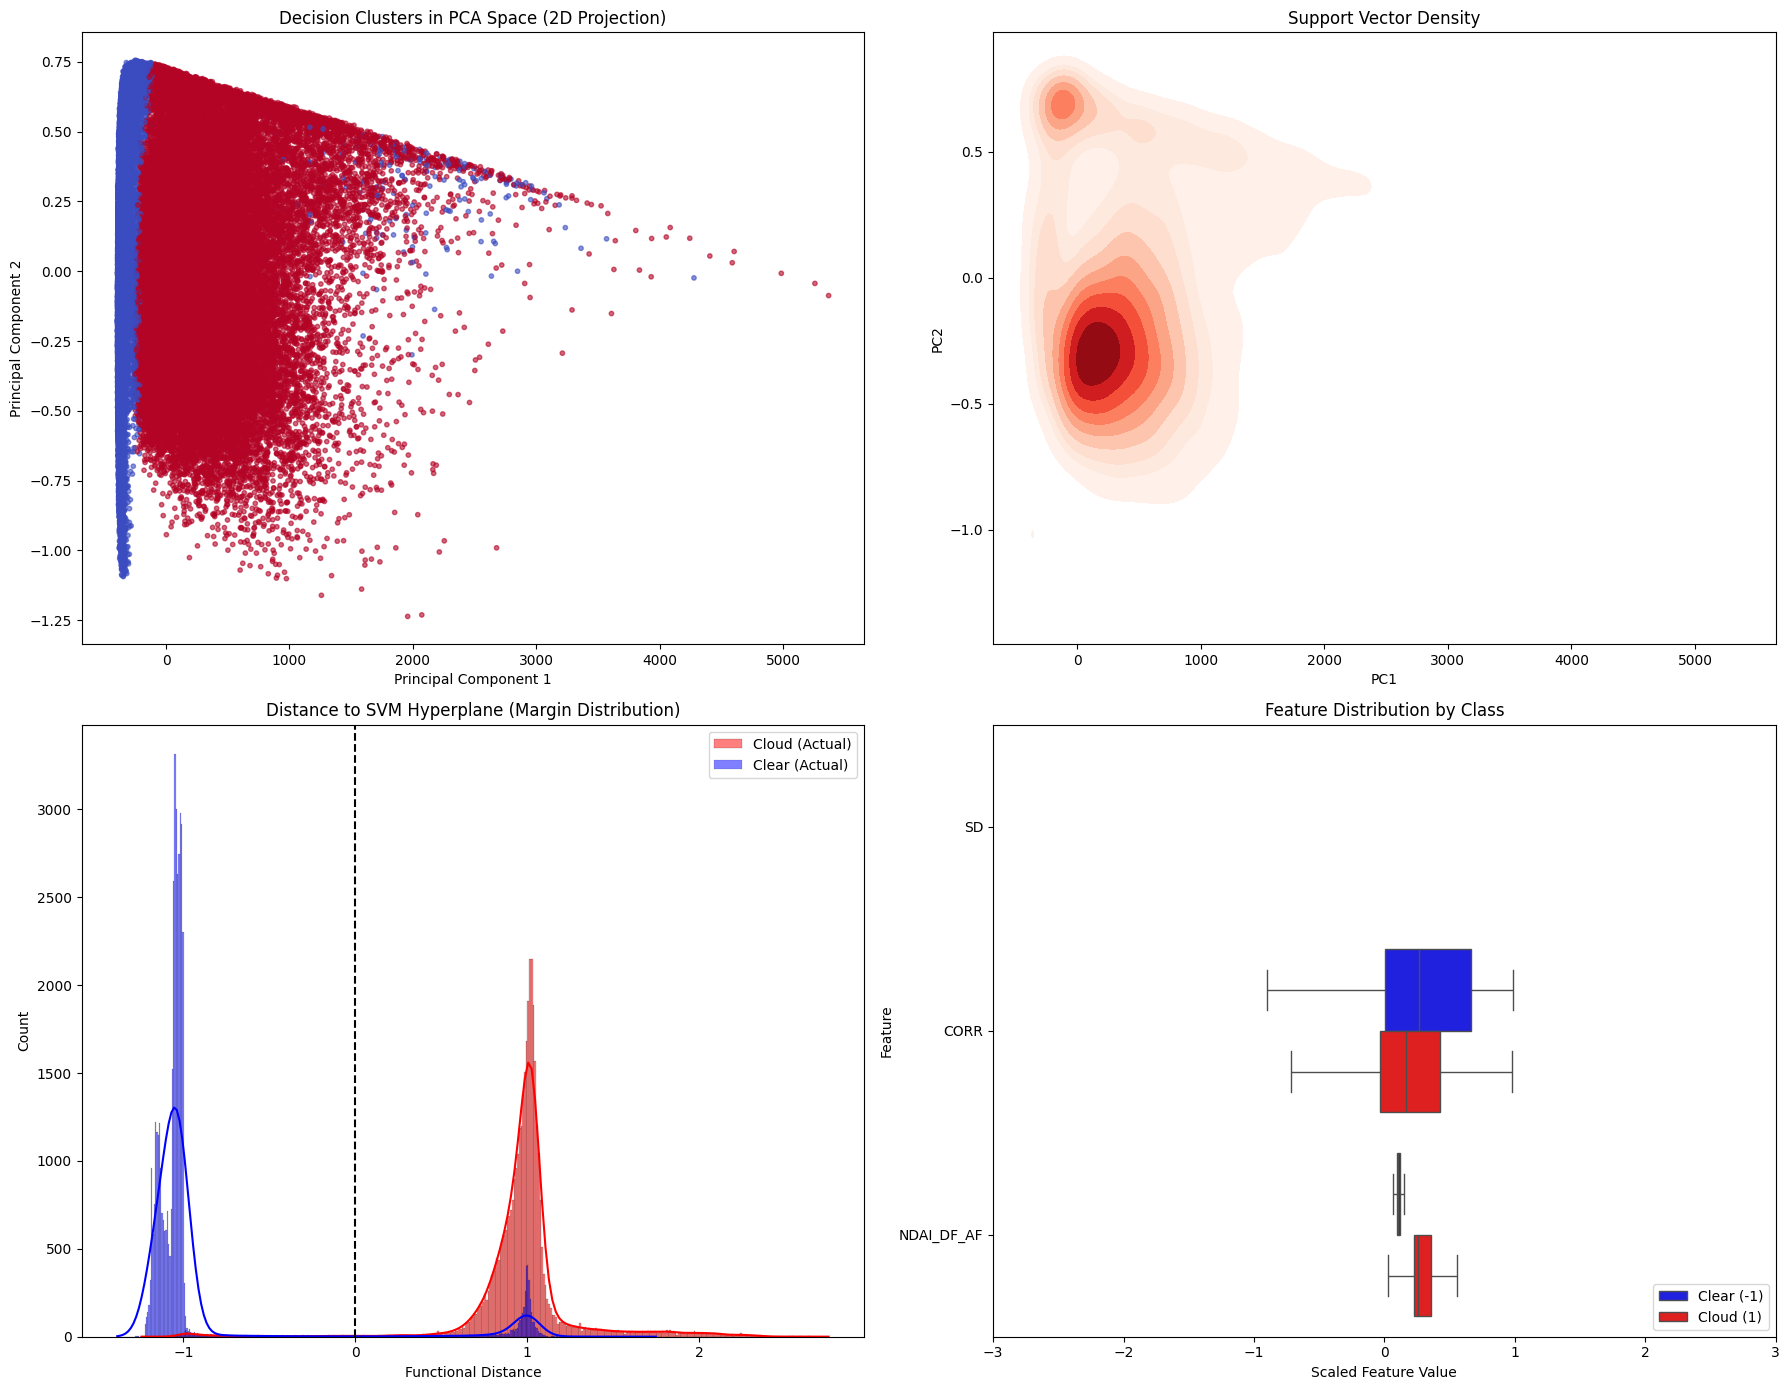

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

def plot_svm_diagnostics(svm_model, X_test, y_test):
    # Setup figure
    fig = plt.subplots(2, 2, figsize=(18, 14))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # Dimensionality reduction for visualization
    # We use PCA to reduce the hyperplane into 2D
    ax1 = plt.subplot(2, 2, 1)
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    
    # Mesh grid to plot the decision boundary
    h = .05  # test
    x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
    y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict over the mesh 
    y_pred = svm_model.predict(X_test)
    ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', s=10, alpha=0.6)
    ax1.set_title('Decision Clusters in PCA Space (2D Projection)')
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')

 
    # Support vectors: the crux of classification: the margins
    ax2 = plt.subplot(2, 2, 2)
    
    decision_values = svm_model.decision_function(X_test)
    # Get index of support vectors
    sv_indices = np.abs(decision_values) <= 1.0
    # We plot the density of support vectors in PCA space
    sns.kdeplot(x=X_test_pca[sv_indices, 0], y=X_test_pca[sv_indices, 1], 
        fill=True, cmap="Reds", ax=ax2)
    ax2.set_title('Support Vector Density')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')

   
    # Hyperplane: Values near 0 are near the boundary. Far from 0 are deep in a class.
    ax3 = plt.subplot(2, 2, 3)
    decision_scores = svm_model.decision_function(X_test)
    
    sns.histplot(decision_scores[y_test == 1], color="red", label="Cloud (Actual)", kde=True, ax=ax3)
    sns.histplot(decision_scores[y_test == -1], color="blue", label="Clear (Actual)", kde=True, ax=ax3)
    ax3.axvline(0, color='black', linestyle='--')
    ax3.set_title('Distance to SVM Hyperplane (Margin Distribution)')
    ax3.set_xlabel('Functional Distance')
    ax3.legend()

    ax4 = plt.subplot(2, 2, 4)

    # 4th Plot plotting out distributions of features by class
    X_plot = X_test.copy()
    X_plot['label'] = y_test

    # Melt data for boxplot
    df_melted = pd.melt(X_plot, id_vars='label', var_name='Feature', value_name='Value')

    # Boxplot for distribution features
    sns.boxplot(data=df_melted, x='Value', y='Feature', hue='label', 
                palette={1: "red", -1: "blue"}, ax=ax4, fliersize=0)

    # Set labels for the legend
    handles, _ = ax4.get_legend_handles_labels()
    ax4.legend(handles, ['Clear (-1)', 'Cloud (1)'], loc='lower right')

    ax4.set_title('Feature Distribution by Class')
    ax4.set_xlabel('Scaled Feature Value')

    # Zoom in in case outliers squeeze the plot
    ax4.set_xlim(-3, 3)

    plt.tight_layout()
    plt.savefig('svm_diagnostics.png')
    plt.show()


#Plot out
plot_svm_diagnostics(svm, X_test_svm, y_test)

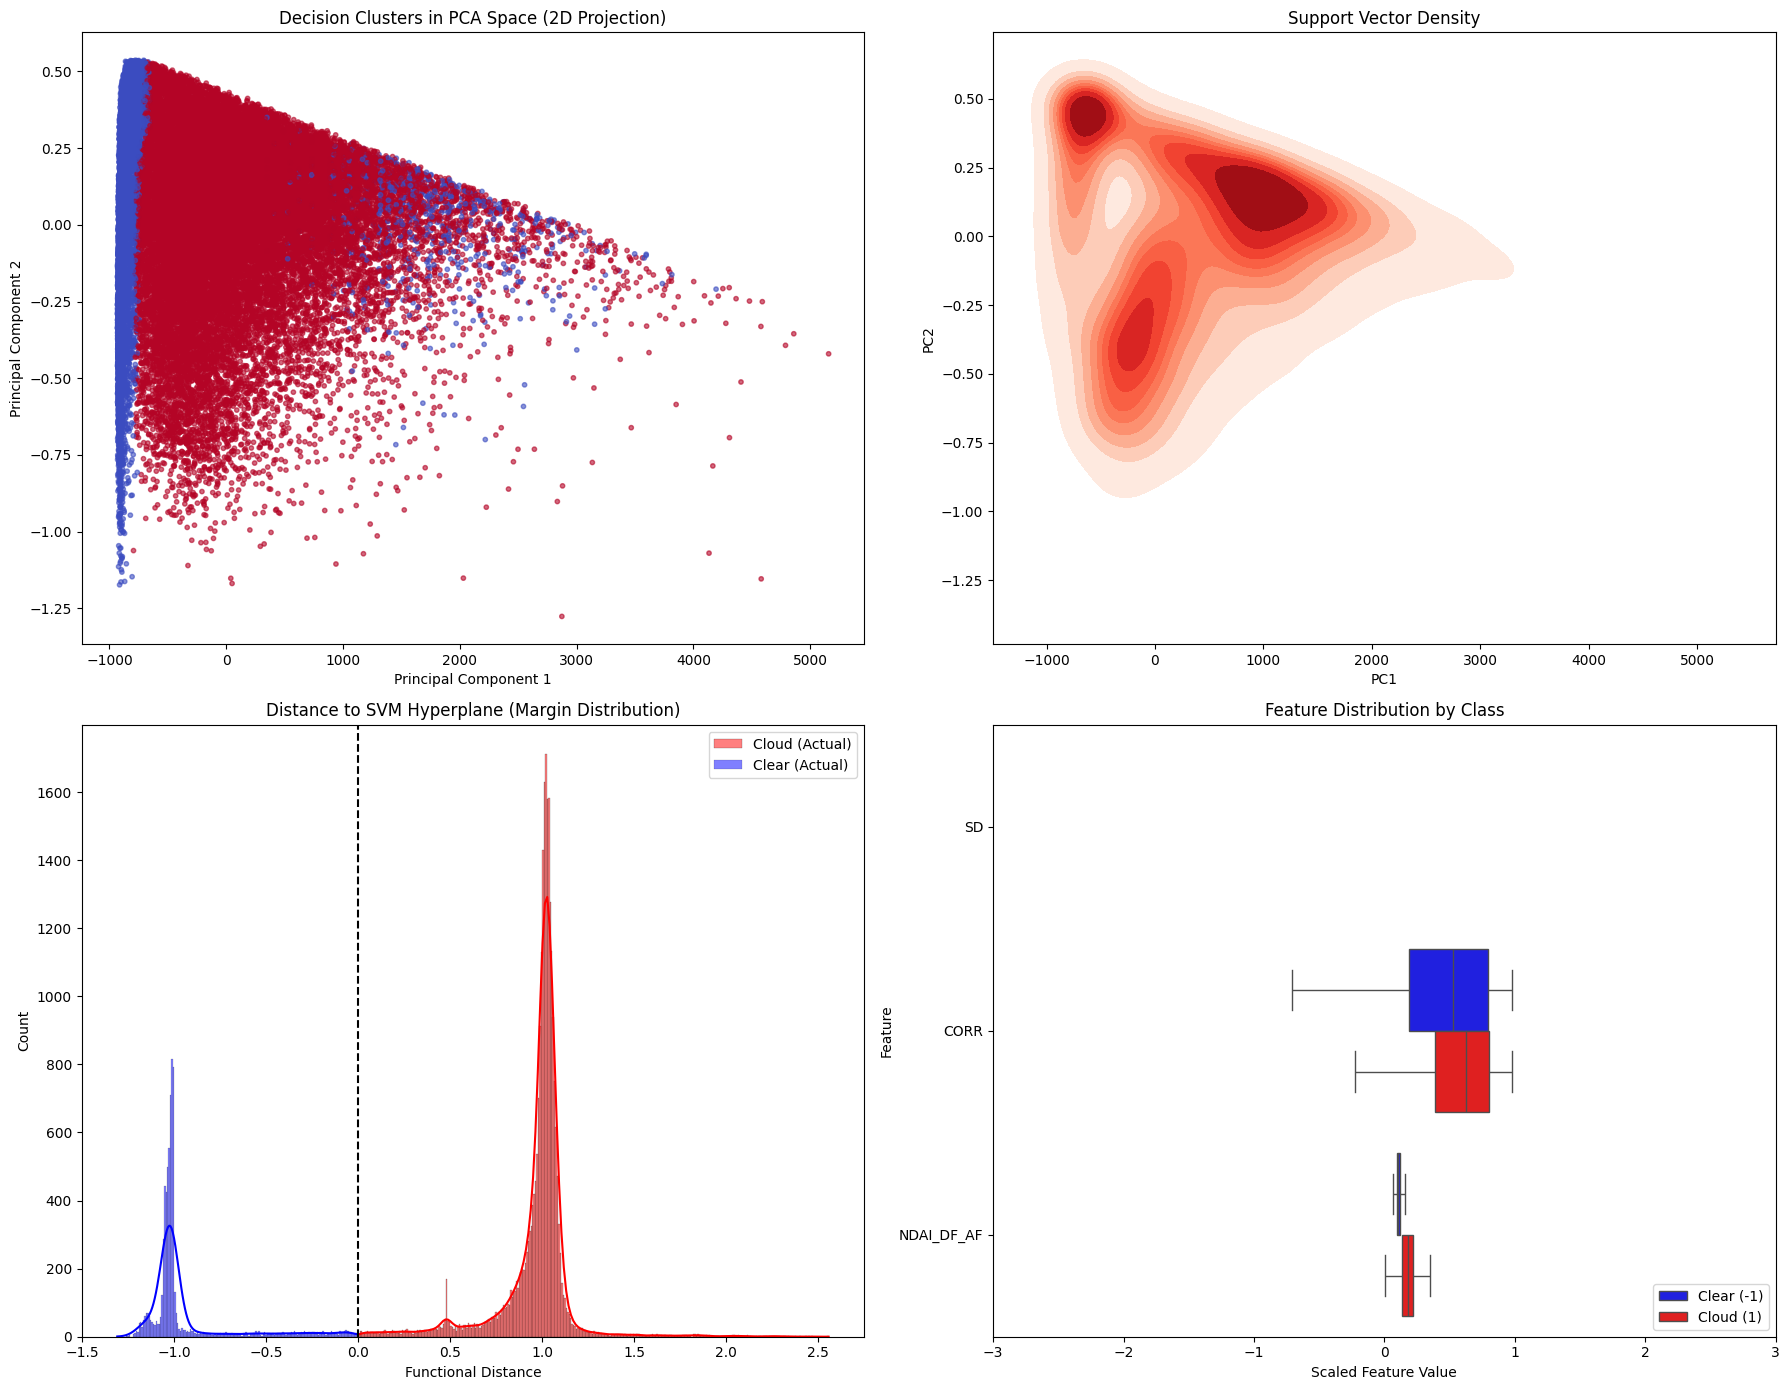

In [9]:
#Additional Testing for unlabeled data

X_svm_unlabled=df_test_zeros[SVM_COLS]
y_pred_unlabled = svm.predict(X_svm_unlabled)

"""
Please note that in this plot things are different.
In the testing of unlabled data, we are seeing if we still have a consistent answer
So the class division is not based on real labels but predicted ones
"""
plot_svm_diagnostics(svm, X_svm_unlabled, y_pred_unlabled)

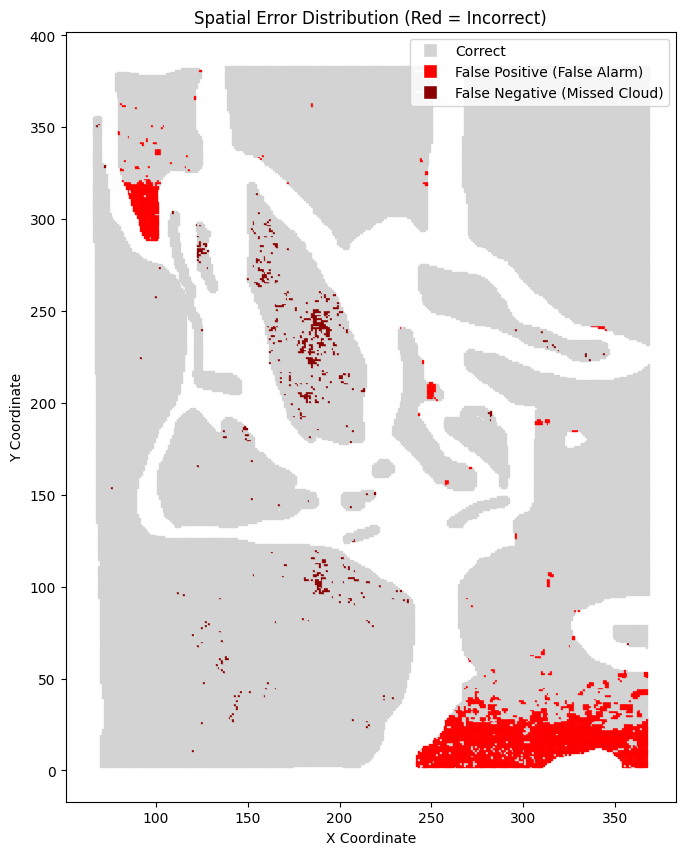

In [4]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import numpy as np

new_df_test = pd.read_csv("../feature_eng_dataset/test_features.csv")

#We include x and y coordinates for plotting
FEATURE_COLS = ["SD", "DF", "CF", "AN", "NDAI_DF_AF"]
LOCATIONS=["x", "y"]

X_location = new_df_test[LOCATIONS]

def plot_spatial_errors(x_coords, y_coords, y_test, y_pred):
    """
    Plots the pixels geographically, color-coded by prediction accuracy.
    """
    # Create an array of colors based on the conditions
    colors = np.empty(len(y_test), dtype=object)
    
    #correct predictions are in grey
    correct_mask = (y_test == y_pred)
    colors[correct_mask] = 'lightgrey'  # Correct predictions in grey
    
    #false positives are in red
    fp_mask = (y_test == -1) & (y_pred == 1)
    colors[fp_mask] = 'red'
    
    #false negatives are in dark red
    fn_mask = (y_test == 1) & (y_pred == -1)
    colors[fn_mask] = 'darkred'

    #plot out
    plt.figure(figsize=(12, 10))
    
    # scatter plots with pixels
    plt.scatter(x_coords, y_coords, c=colors, s=1, marker='s')
    
    # legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='lightgrey', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='False Positive (False Alarm)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='False Negative (Missed Cloud)', markerfacecolor='darkred', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Spatial Error Distribution (Red = Incorrect)')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.gca().set_aspect('equal', adjustable='box') # Keep pixel aspect ratio
    plt.show()


# Plot out
plot_spatial_errors(X_location['x'], X_location['y'], y_test, y_pred_svm)

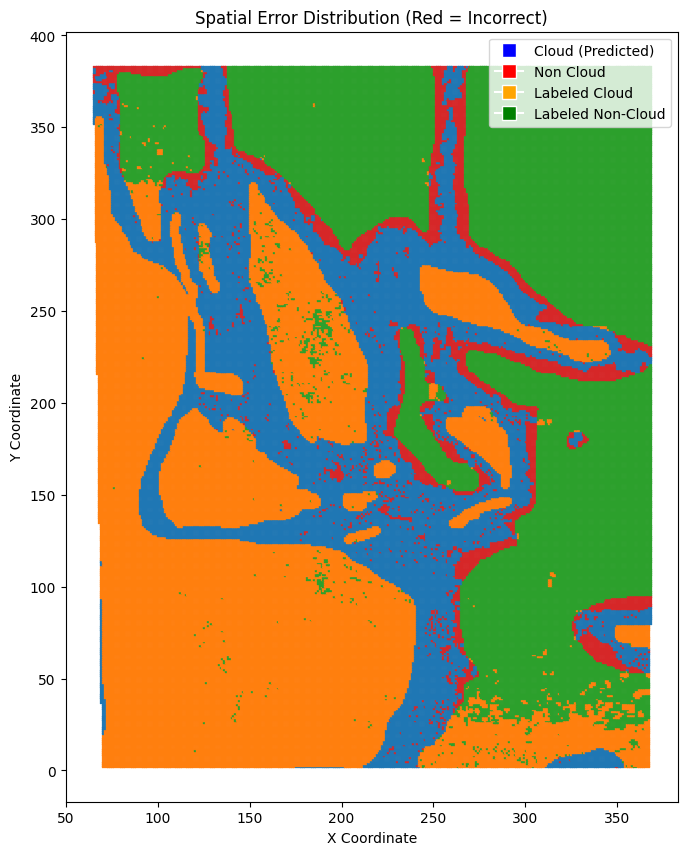

In [ ]:
#For unlabled data
unlabled_df_test = pd.read_csv("../feature_eng_dataset/test_features_opt.csv")
#unlabled_df_test=unlabled_df_test[unlabled_df_test['label']==0]
LOCATIONS=["x","y"]

X_location_unlab = unlabled_df_test[LOCATIONS]
x_coords = X_location_unlab['x']
y_coords = X_location_unlab['y']

X_svm_unlabled=unlabled_df_test[SVM_COLS]
y_pred_unlabled = svm.predict(X_svm_unlabled)
real_labels_unlabled=unlabled_df_test['label']

# Create an array of colors based on the conditions
colors = np.empty(len(y_pred_unlabled), dtype=object)

#correct predictions are in grey
correct_mask = (y_pred_unlabled == 1) & (real_labels_unlabled == 0)
colors[correct_mask] = '#1f77b4'  # Cloud predictions in blue

#false positives are in red
fp_mask = (y_pred_unlabled == -1) & (real_labels_unlabled == 0)
colors[fp_mask] = '#d62728' #Non-cloud in red
#Labeled cloud
rc_mask= (y_pred_unlabled == 1) & (real_labels_unlabled != 0)
colors[rc_mask] = '#ff7f0e' #Labeled cloud in orange

#Labeled non-cloud
nc_mask = (y_pred_unlabled == -1) & (real_labels_unlabled != 0)
colors[nc_mask] = '#2ca02c' #Labeled non-cloud in green
#plot out
plt.figure(figsize=(12, 10))

# scatter plots with pixels
plt.scatter(x_coords, y_coords, c=colors, s=1, marker='s')

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Cloud (Predicted)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Non Cloud', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Labeled Cloud', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Labeled Non-Cloud', markerfacecolor='green', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title('Spatial Error Distribution (Red = Incorrect)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.gca().set_aspect('equal', adjustable='box') # Keep pixel aspect ratio
plt.show()

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Scale features before Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\nPerforming Variable Selection (Lasso L1)...")
# We use L1 Lasso to boost sparsity in selection
selector_model = LogisticRegression(penalty='l1', C=0.01, solver='liblinear', random_state=42)
selector = SelectFromModel(selector_model)

# Select the selected features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_val_selected = selector.transform(X_val_scaled)


# Get mask of selected features to see which ones survived
selected_features = X_train.columns[selector.get_support()]
print(f"Features selected: {len(selected_features)}")
print(f"Selected Names: {list(selected_features)}")

# Fit Logistic Regression
selector_model.fit(X_train_selected, y_train)
lasso_preds = selector_model.predict(X_val_selected)


#Print our results
print("SUMMARY OF RESULTS")

print(f"Lasso Logistic Regression Accuracy: {accuracy_score(y_val, lasso_preds)}")
print("Detailed Lasso Classification Report:")
print(classification_report(y_val, lasso_preds))
print(f"Lasso Logistic Regression AUC: {roc_auc_score(y_val, lasso_preds)}")


Performing Variable Selection (Lasso L1)...


/jet/home/gxu9/.conda/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/jet/home/gxu9/.conda/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Features selected: 7
Selected Names: ['SD', 'CORR', 'DF', 'BF', 'AF', 'AN', 'NDAI_DF_AF']


/jet/home/gxu9/.conda/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/jet/home/gxu9/.conda/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


SUMMARY OF RESULTS
Lasso Logistic Regression Accuracy: 0.4920945008398452
Detailed Lasso Classification Report:
              precision    recall  f1-score   support

        -1.0       0.62      0.43      0.51     33528
         1.0       0.40      0.59      0.48     21244

    accuracy                           0.49     54772
   macro avg       0.51      0.51      0.49     54772
weighted avg       0.54      0.49      0.50     54772

Lasso Logistic Regression AUC: 0.5109097319030239


In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


# In this process we will perform stepwise selection for the best performance in variable selection
print(f"Starting Stepwise Selection on {X_train.shape[1]} features...")

# We use liblinear because we have small feature sets and binary classification
lr = LogisticRegression(solver='liblinear', class_weight='balanced')

# n_features_to_select='auto' uses a tolerance, because we do not know any number to specify
sfs = SequentialFeatureSelector(
    lr, 
    n_features_to_select=5, 
    direction='forward', # 'forward' because we want as few features as possible
    scoring='accuracy',
    cv=3,
    n_jobs=-1 #utilize all cores
)

#Fit the model
sfs.fit(X_train, y_train)

# Now we use only selected variables for evaluation
X_train_stepwise = sfs.transform(X_train)
X_val_stepwise = sfs.transform(X_val)
X_test_stepwise = sfs.transform(X_test)

# Print out selected features
selected_indices = sfs.get_support()
feature_names = X_train.columns[selected_indices]
print(f"Stepwise Selected Features: {list(feature_names)}")

#Fit once more, now we only use selected features
lr.fit(X_train_stepwise, y_train)
preds = lr.predict(X_val_stepwise)
pred_test = lr.predict(X_test_stepwise)

print(f"Final Stepwise Logistic Regression Accuracy: {accuracy_score(y_val, preds)}")
print(f"Final Stepwise Logistic Regression Test Accuracy: {accuracy_score(y_test, pred_test)}")
print(f"Detailed Stepwise Classification Report:{classification_report(y_test, pred_test)}")
print(f"Final Stepwise Logistic Regression AUC: {roc_auc_score(y_test, pred_test)}")

Starting Stepwise Selection on 9 features...


Stepwise Selected Features: ['SD', 'DF', 'CF', 'AN', 'NDAI_DF_AF']
Final Stepwise Logistic Regression Accuracy: 0.7887971956474111
Final Stepwise Logistic Regression Test Accuracy: 0.8151139700059695
Detailed Stepwise Classification Report:              precision    recall  f1-score   support

        -1.0       0.77      0.92      0.84     42830
         1.0       0.89      0.70      0.78     39253

    accuracy                           0.82     82083
   macro avg       0.83      0.81      0.81     82083
weighted avg       0.83      0.82      0.81     82083

Final Stepwise Logistic Regression AUC: 0.8101452208125907


In [7]:
print(lr.coef_)
print(lr.intercept_)

[[ 4.78684167e-03  1.11788583e-04 -3.48833446e-04  2.08933316e-04
   8.88420137e-07]]
[3.91303535e-06]


/tmp/ipykernel_1057305/1290073849.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis', ax=axes[1, 1])


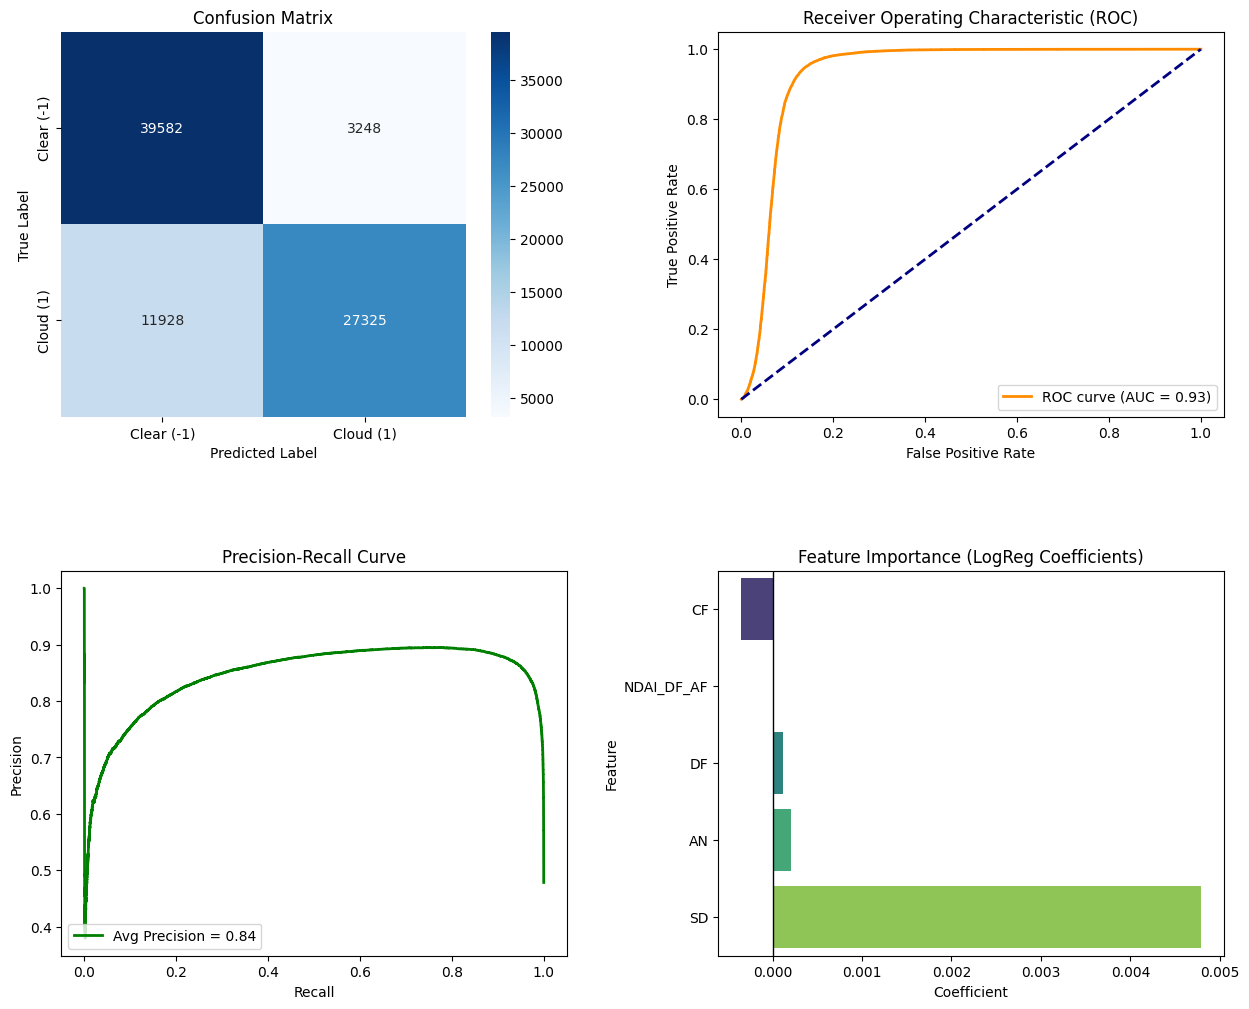

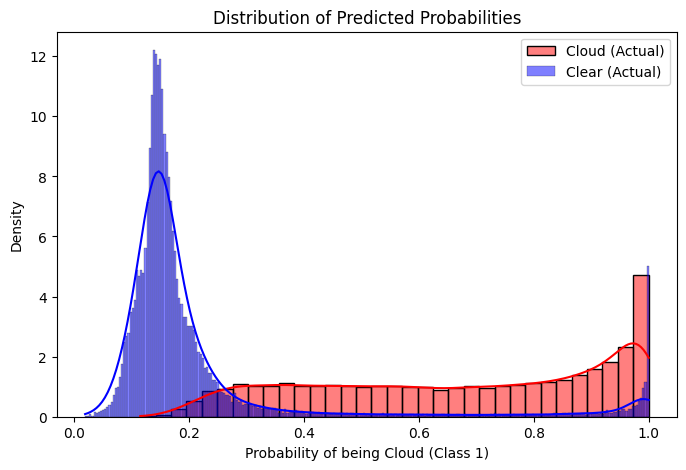

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score
)

# Here are the predictions and probabilities data
y_pred = lr.predict(X_test_stepwise)
y_prob = lr.predict_proba(X_test_stepwise)[:, 1]  # Probabilities for the positive class (1)

# Set up the figure for multiple plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

#Custom Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xticklabels(['Clear (-1)', 'Cloud (1)'])
axes[0, 0].set_yticklabels(['Clear (-1)', 'Cloud (1)'])

#ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.2f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc="lower left")


# Visualizing which of the 9 features the model relies on most
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0] #They are all scaled so you can use coef directly
}).sort_values(by='Coefficient')

sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Feature Importance (LogReg Coefficients)')
axes[1, 1].axvline(0, color='black', lw=1)

plt.show()

# Due to the double peaks feature discovered in EDA
# We want to plot out if our LOG Reg model actually reflects that
plt.figure(figsize=(8, 5))
sns.histplot(y_prob[y_test == 1], color="red", label="Cloud (Actual)", kde=True, stat="density", alpha=0.5)
sns.histplot(y_prob[y_test == -1], color="blue", label="Clear (Actual)", kde=True, stat="density", alpha=0.5)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of being Cloud (Class 1)')
plt.legend()
plt.show()

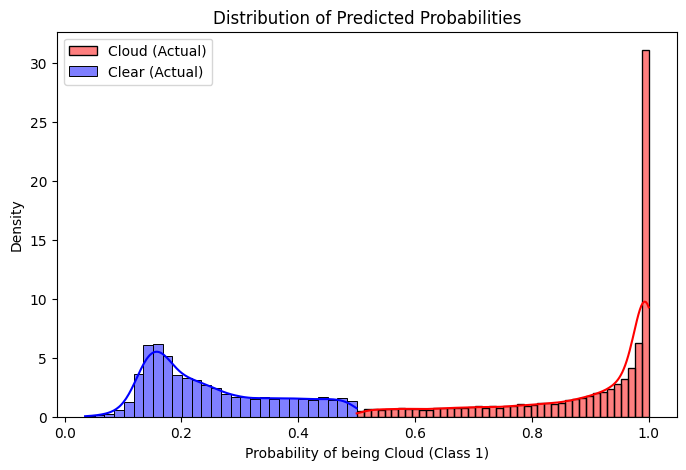

In [13]:
X_stepwise_unlabled=sfs.transform(X_test_unlabled)
y_stepwise_unlabled_pred = lr.predict(X_stepwise_unlabled)
y_unlabled_prob = lr.predict_proba(X_stepwise_unlabled)[:, 1]

plt.figure(figsize=(8, 5))
sns.histplot(y_unlabled_prob[y_stepwise_unlabled_pred == 1], color="red", label="Cloud (Actual)", kde=True, stat="density", alpha=0.5)
sns.histplot(y_unlabled_prob[y_stepwise_unlabled_pred == -1], color="blue", label="Clear (Actual)", kde=True, stat="density", alpha=0.5)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of being Cloud (Class 1)')
plt.legend()
plt.show()

X_train : (70826, 9)
X_test  : (82083, 9)
X_val  : (54772, 9)
Number of AE features: 32
Features: ['SD', 'DF', 'CF', 'AN', 'NDAI_DF_AF']


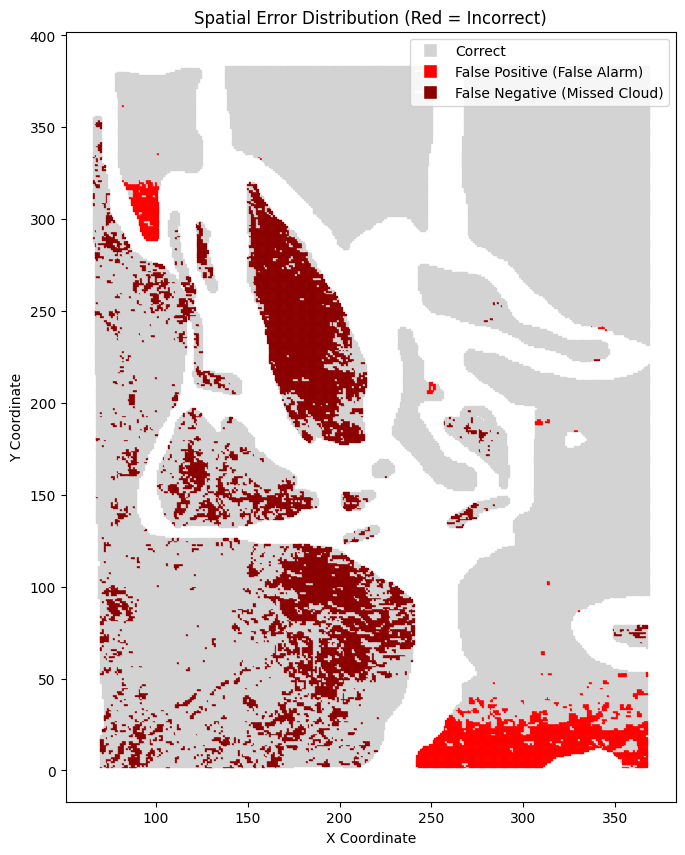

In [9]:
# Teammate load cell
import pandas as pd
import numpy as np


new_df_test = pd.read_csv("../feature_eng_dataset/test_features.csv")



FEATURE_COLS = ["SD", "DF", "CF", "AN", "NDAI_DF_AF"]
LOCATIONS=["x", "y"]


X_location = new_df_test[LOCATIONS]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"X_val  : {X_val.shape}")
print(f"Number of AE features: {len(ae_cols)}")
print(f"Features: {FEATURE_COLS}")

y_pred = lr.predict(X_test_stepwise)

import matplotlib.pyplot as plt
import numpy as np

def plot_spatial_errors(x_coords, y_coords, y_test, y_pred):
    """
    Plots the pixels geographically, color-coded by prediction accuracy.
    """
    # Create an array of colors based on the conditions
    colors = np.empty(len(y_test), dtype=object)
    
    # Logic for categories
    # Correct Predictions (Grey)
    correct_mask = (y_test == y_pred)
    colors[correct_mask] = 'lightgrey'  # Correct predictions in grey
    
    # False Positives (Red) - Model said Cloud, but it was Clear
    fp_mask = (y_test == -1) & (y_pred == 1)
    colors[fp_mask] = 'red'
    
    # False Negatives (Dark Red) - Model said Clear, but it was Cloud
    fn_mask = (y_test == 1) & (y_pred == -1)
    colors[fn_mask] = 'darkred'

    # Plotting
    plt.figure(figsize=(12, 10))
    
    # We use scatter with s=1 (or very small) to represent individual pixels
    plt.scatter(x_coords, y_coords, c=colors, s=1, marker='s')
    
    # Add a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='lightgrey', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='False Positive (False Alarm)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='False Negative (Missed Cloud)', markerfacecolor='darkred', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Spatial Error Distribution (Red = Incorrect)')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.gca().set_aspect('equal', adjustable='box') # Keep pixel aspect ratio
    plt.show()

# Run the function
# Assuming your x and y coordinates are stored in variables x_coords and y_coords
plot_spatial_errors(X_location['x'], X_location['y'], y_test, y_pred)

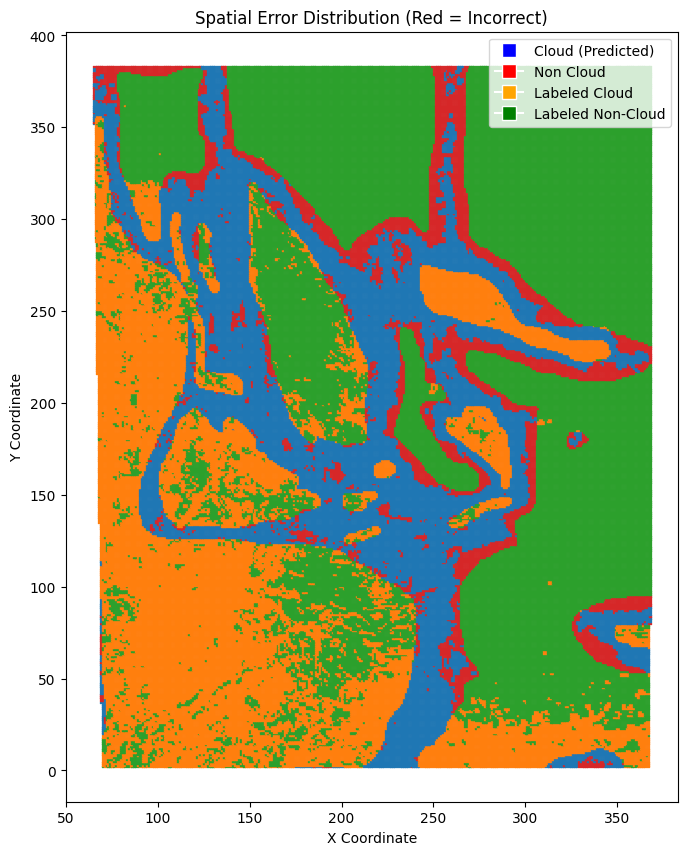

In [19]:
#Replicate on the Unlabeled data


X_location_unlab = unlabled_df_test[LOCATIONS]
x_coords = X_location_unlab['x']
y_coords = X_location_unlab['y']


X_location_unlab = unlabled_df_test[LOCATIONS]
x_coords = X_location_unlab['x']
y_coords = X_location_unlab['y']

X_svm_unlabled=sfs.transform(unlabled_df_test[FEATURE_COLS])
y_pred_unlabled = lr.predict(X_svm_unlabled)
real_labels_unlabled=unlabled_df_test['label']

# Create an array of colors based on the conditions
colors = np.empty(len(y_pred_unlabled), dtype=object)

#correct predictions are in grey
correct_mask = (y_pred_unlabled == 1) & (real_labels_unlabled == 0)
colors[correct_mask] = '#1f77b4'  # Cloud predictions in blue

#false positives are in red
fp_mask = (y_pred_unlabled == -1) & (real_labels_unlabled == 0)
colors[fp_mask] = '#d62728' #Non-cloud in red

#Labeled cloud
rc_mask= (y_pred_unlabled == 1) & (real_labels_unlabled != 0)
colors[rc_mask] = '#ff7f0e' #Labeled cloud in orange

#Labeled non-cloud
nc_mask = (y_pred_unlabled == -1) & (real_labels_unlabled != 0)
colors[nc_mask] = '#2ca02c' #Labeled non-cloud in green

#plot out
plt.figure(figsize=(12, 10))

# scatter plots with pixels
plt.scatter(x_coords, y_coords, c=colors, s=1, marker='s')

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Cloud (Predicted)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Non Cloud', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Labeled Cloud', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Labeled Non-Cloud', markerfacecolor='green', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title('Spatial Error Distribution (Red = Incorrect)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.gca().set_aspect('equal', adjustable='box') # Keep pixel aspect ratio
plt.show()